In [ ]:
import tensorflow as tf

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [3]:
import numpy as np
from numpy import cov
from numpy import trace
from numpy import iscomplexobj
from numpy import asarray
from numpy.random import randint
from scipy.linalg import sqrtm

from keras.applications.inception_v3 import InceptionV3
from keras.applications.inception_v3 import preprocess_input as inception_preprocess

from keras.applications.resnet import ResNet50
from keras.applications.resnet import preprocess_input as resnet_preprocess

from keras.datasets.mnist import load_data
from skimage.transform import resize

In [4]:
import imageio.v2 as imageio
import matplotlib.pyplot as plt

In [5]:
# scale an array of images to a new size
def scale_images(images, new_shape):
    images_list = list()
    for image in images:
        # resize with nearest neighbor interpolation
        new_image = resize(image, new_shape, 0)
        # store
        images_list.append(new_image)
    return asarray(images_list)

Calculate frechet distance using a given model

In [6]:
def calculate_fid(model, images1, images2):
    # calculate activations
    act1 = model.predict(images1)
    act2 = model.predict(images2)
    # calculate mean and covariance statistics
    mu1, sigma1 = act1.mean(axis=0), cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), cov(act2, rowvar=False)
    # calculate sum squared difference between means
    ssdiff = np.sum((mu1 - mu2)**2.0)
    # calculate sqrt of product between cov
    covmean = sqrtm(sigma1.dot(sigma2))
    # check and correct imaginary numbers from sqrt
    if iscomplexobj(covmean):
        covmean = covmean.real
    # calculate score
    fid = ssdiff + trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

Prepare the classification model:

In [7]:
in_shape = (1024,1024,3)

In [8]:
model = InceptionV3(include_top=False, pooling='avg', input_shape=in_shape)
# model = ResNet50(include_top=False, pooling='avg', input_shape=in_shape)

In [9]:
original_img = "C:/code/ComfyUI_evaluate/original/1.png"

img_1 = "C:/code/ComfyUI_evaluate/output/Textmentation/0/D_E_S_Tmentation_1_0_00001_.png"
img_2 = "C:/code/ComfyUI_evaluate/output/D_E_S_Tmentation/0/Segmentation_2_0_00001_.png"
img_3 = "C:/code/ComfyUI_evaluate/output/Segmentation/0/Segmentation_3_0_00001_.png"
img_4 = "C:/code/ComfyUI_evaluate/output/Segmentation/0/Segmentation_4_0_00001_.png"

In [10]:
image_0 = imageio.imread(original_img)
image_0 = image_0.astype('float32')/255
images_real = scale_images(np.array([image_0, image_0, image_0, image_0]), in_shape)

In [11]:
print(images_real.shape)

(4, 1024, 1024, 3)


In [12]:
image_1 = imageio.imread(img_1)
image_1 = image_1.astype('float32')/255
print(image_1.shape)

image_2 = imageio.imread(img_2)
image_2 = image_2.astype('float32')/255
print(image_2.shape)

image_3 = imageio.imread(img_3)
image_3 = image_3.astype('float32')/255
print(image_3.shape)

image_4 = imageio.imread(img_4)
image_4 = image_4.astype('float32')/255
print(image_4.shape)

images_gen = scale_images(np.array([image_1, image_2, image_3, image_4]), in_shape)

FileNotFoundError: No such file: 'C:\code\ComfyUI_evaluate\output\Textmentation\0\D_E_S_Tmentation_1_0_00001_.png'

In [ ]:
print(images_gen.shape)

NameError: name 'images_gen' is not defined

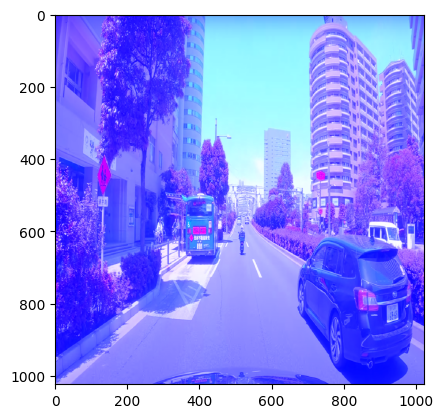

In [ ]:
plt.imshow(images_real[0])
plt.show()

In [13]:
# images_real = inception_preprocess(images_real)
# images_gen = inception_preprocess(images_gen)
images_real = resnet_preprocess(images_real)
images_gen = resnet_preprocess(images_gen)

NameError: name 'images_gen' is not defined

In [16]:
# fid between images1 and images1
fid = calculate_fid(model, images_real, images_real)
print('FID (same): %.3f' % fid)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
FID (same): 0.000


In [15]:
# fid between images1 and images2
fid = calculate_fid(model, images_real, images_gen)
print('FID (different): %.3f' % fid)

NameError: name 'images_gen' is not defined

Individual image:

### Image 1

In [17]:
import os
import glob

original_img_1 = "C:/code/ComfyUI/input/original/1.png"
original_img_2 = "C:/code/ComfyUI/input/original/1.png"
original_img_3 = "C:/code/ComfyUI/input/original/1.png"
original_img_4 = "C:/code/ComfyUI/input/original/1.png"
original_img_5 = "C:/code/ComfyUI/input/original/1.png"
original_img_6 = "C:/code/ComfyUI/input/original/1.png"
original_img_7 = "C:/code/ComfyUI/input/original/1.png"
original_img_8 = "C:/code/ComfyUI/input/original/1.png"
original_img_9 = "C:/code/ComfyUI/input/original/1.png"
original_img_10 = "C:/code/ComfyUI/input/original/1.png"

img_1_1 = "C:/code/ComfyUI/output/Text/AWGN/0/Text_AWGN_0_1_00001_.png"
img_1_2 = "C:/code/ComfyUI/output/Text/AWGN/6/Text_AWGN_6_1_00001_.png"
img_1_3 = "C:/code/ComfyUI/output/Text/AWGN/12/Text_AWGN_12_1_00002_.png"

img_2_1 = "C:/code/ComfyUI/output/Text/AWGN/0/Text_AWGN_0_1_00001_.png"
img_2_2 = "C:/code/ComfyUI/output/Text/AWGN/6/Text_AWGN_6_1_00001_.png"
img_2_3 = "C:/code/ComfyUI/output/Text/AWGN/12/Text_AWGN_12_1_00002_.png"

img_3_1 = "C:/code/ComfyUI/output/Text/AWGN/0/Text_AWGN_0_1_00001_.png"
img_3_2 = "C:/code/ComfyUI/output/Text/AWGN/6/Text_AWGN_6_1_00001_.png"
img_3_3 = "C:/code/ComfyUI/output/Text/AWGN/12/Text_AWGN_12_1_00002_.png"

img_4_1 = "C:/code/ComfyUI/output/Text/AWGN/0/Text_AWGN_0_1_00001_.png"
img_4_2 = "C:/code/ComfyUI/output/Text/AWGN/6/Text_AWGN_6_1_00001_.png"
img_4_3 = "C:/code/ComfyUI/output/Text/AWGN/12/Text_AWGN_12_1_00002_.png"

img_5_1 = "C:/code/ComfyUI/output/Text/AWGN/0/Text_AWGN_0_1_00001_.png"
img_5_2 = "C:/code/ComfyUI/output/Text/AWGN/6/Text_AWGN_6_1_00001_.png"
img_5_3 = "C:/code/ComfyUI/output/Text/AWGN/12/Text_AWGN_12_1_00002_.png"

img_6_1 = "C:/code/ComfyUI/output/Text/AWGN/0/Text_AWGN_0_1_00001_.png"
img_6_2 = "C:/code/ComfyUI/output/Text/AWGN/6/Text_AWGN_6_1_00001_.png"
img_6_3 = "C:/code/ComfyUI/output/Text/AWGN/12/Text_AWGN_12_1_00002_.png"

img_7_1 = "C:/code/ComfyUI/output/Text/AWGN/0/Text_AWGN_0_1_00001_.png"
img_7_2 = "C:/code/ComfyUI/output/Text/AWGN/6/Text_AWGN_6_1_00001_.png"
img_7_3 = "C:/code/ComfyUI/output/Text/AWGN/12/Text_AWGN_12_1_00002_.png"

img_8_1 = "C:/code/ComfyUI/output/Text/AWGN/0/Text_AWGN_0_1_00001_.png"
img_8_2 = "C:/code/ComfyUI/output/Text/AWGN/6/Text_AWGN_6_1_00001_.png"
img_8_3 = "C:/code/ComfyUI/output/Text/AWGN/12/Text_AWGN_12_1_00002_.png"

img_9_1 = "C:/code/ComfyUI/output/Text/AWGN/0/Text_AWGN_0_1_00001_.png"
img_9_2 = "C:/code/ComfyUI/output/Text/AWGN/6/Text_AWGN_6_1_00001_.png"
img_9_3 = "C:/code/ComfyUI/output/Text/AWGN/12/Text_AWGN_12_1_00002_.png"

img_10_1 = "C:/code/ComfyUI/output/Text/AWGN/0/Text_AWGN_0_1_00001_.png"
img_10_2 = "C:/code/ComfyUI/output/Text/AWGN/6/Text_AWGN_6_1_00001_.png"
img_10_3 = "C:/code/ComfyUI/output/Text/AWGN/12/Text_AWGN_12_1_00002_.png"

image_1_0 = imageio.imread(original_img_1)
image_1_0 = image_1_0.astype('float32')/255

image_2_0 = imageio.imread(original_img_2)
image_2_0 = image_2_0.astype('float32')/255

image_3_0 = imageio.imread(original_img_3)
image_3_0 = image_3_0.astype('float32')/255

image_4_0 = imageio.imread(original_img_4)
image_4_0 = image_4_0.astype('float32')/255

image_5_0 = imageio.imread(original_img_5)
image_5_0 = image_5_0.astype('float32')/255

image_6_0 = imageio.imread(original_img_6)
image_6_0 = image_6_0.astype('float32')/255

image_7_0 = imageio.imread(original_img_7)
image_7_0 = image_7_0.astype('float32')/255

image_8_0 = imageio.imread(original_img_8)
image_8_0 = image_8_0.astype('float32')/255

image_9_0 = imageio.imread(original_img_9)
image_9_0 = image_9_0.astype('float32')/255

image_10_0 = imageio.imread(original_img_10)
image_10_0 = image_10_0.astype('float32')/255

# Generated images:
image_1_1 = imageio.imread(img_1_1)
image_1_1 = image_1_1.astype('float32')/255
image_1_2 = imageio.imread(img_1_2)
image_1_2 = image_1_2.astype('float32')/255
image_1_3 = imageio.imread(img_1_3)
image_1_3 = image_1_3.astype('float32')/255

image_2_1 = imageio.imread(img_2_1)
image_2_1 = image_2_1.astype('float32')/255
image_2_2 = imageio.imread(img_2_2)
image_2_2 = image_2_2.astype('float32')/255
image_2_3 = imageio.imread(img_2_3)
image_2_3 = image_2_3.astype('float32')/255

image_3_1 = imageio.imread(img_3_1)
image_3_1 = image_3_1.astype('float32')/255
image_3_2 = imageio.imread(img_3_2)
image_3_2 = image_3_2.astype('float32')/255
image_3_3 = imageio.imread(img_3_3)
image_3_3 = image_3_3.astype('float32')/255

image_4_1 = imageio.imread(img_4_1)
image_4_1 = image_4_1.astype('float32')/255
image_4_2 = imageio.imread(img_4_2)
image_4_2 = image_4_2.astype('float32')/255
image_4_3 = imageio.imread(img_4_3)
image_4_3 = image_4_3.astype('float32')/255

image_5_1 = imageio.imread(img_5_1)
image_5_1 = image_5_1.astype('float32')/255
image_5_2 = imageio.imread(img_5_2)
image_5_2 = image_5_2.astype('float32')/255
image_5_3 = imageio.imread(img_5_3)
image_5_3 = image_5_3.astype('float32')/255

image_6_1 = imageio.imread(img_6_1)
image_6_1 = image_6_1.astype('float32')/255
image_6_2 = imageio.imread(img_6_2)
image_6_2 = image_6_2.astype('float32')/255
image_6_3 = imageio.imread(img_6_3)
image_6_3 = image_6_3.astype('float32')/255

image_7_1 = imageio.imread(img_7_1)
image_7_1 = image_7_1.astype('float32')/255
image_7_2 = imageio.imread(img_7_2)
image_7_2 = image_7_2.astype('float32')/255
image_7_3 = imageio.imread(img_7_3)
image_7_3 = image_7_3.astype('float32')/255

image_8_1 = imageio.imread(img_8_1)
image_8_1 = image_8_1.astype('float32')/255
image_8_2 = imageio.imread(img_8_2)
image_8_2 = image_8_2.astype('float32')/255
image_8_3 = imageio.imread(img_8_3)
image_8_3 = image_8_3.astype('float32')/255

image_9_1 = imageio.imread(img_9_1)
image_9_1 = image_9_1.astype('float32')/255
image_9_2 = imageio.imread(img_9_2)
image_9_2 = image_9_2.astype('float32')/255
image_9_3 = imageio.imread(img_9_3)
image_9_3 = image_9_3.astype('float32')/255

image_10_1 = imageio.imread(img_10_1)
image_10_1 = image_10_1.astype('float32')/255
image_10_2 = imageio.imread(img_10_2)
image_10_2 = image_10_2.astype('float32')/255
image_10_3 = imageio.imread(img_10_3)
image_10_3 = image_10_3.astype('float32')/255



# Create images for classification
image_real_1 = scale_images(np.array([image_1_0, image_1_0]), in_shape)
image_real_2 = scale_images(np.array([image_2_0, image_2_0]), in_shape)
image_real_3 = scale_images(np.array([image_3_0, image_3_0]), in_shape)
image_real_4 = scale_images(np.array([image_4_0, image_4_0]), in_shape)
image_real_5 = scale_images(np.array([image_5_0, image_5_0]), in_shape)
image_real_6 = scale_images(np.array([image_6_0, image_6_0]), in_shape)
image_real_7 = scale_images(np.array([image_7_0, image_7_0]), in_shape)
image_real_8 = scale_images(np.array([image_8_0, image_8_0]), in_shape)
image_real_9 = scale_images(np.array([image_9_0, image_9_0]), in_shape)
image_real_10 = scale_images(np.array([image_10_0, image_10_0]), in_shape)

image_gen_1_1 = images_gen = scale_images(np.array([image_1_1, image_1_1]), in_shape)
image_gen_1_2 = images_gen = scale_images(np.array([image_1_2, image_1_2]), in_shape)
image_gen_1_3 = images_gen = scale_images(np.array([image_1_3, image_1_3]), in_shape)

image_gen_2_1 = images_gen = scale_images(np.array([image_2_1, image_2_1]), in_shape)
image_gen_2_2 = images_gen = scale_images(np.array([image_2_2, image_2_2]), in_shape)
image_gen_2_3 = images_gen = scale_images(np.array([image_2_3, image_2_3]), in_shape)

image_gen_3_1 = images_gen = scale_images(np.array([image_3_1, image_3_1]), in_shape)
image_gen_3_2 = images_gen = scale_images(np.array([image_3_2, image_3_2]), in_shape)
image_gen_3_3 = images_gen = scale_images(np.array([image_3_3, image_3_3]), in_shape)

image_gen_4_1 = images_gen = scale_images(np.array([image_4_1, image_4_1]), in_shape)
image_gen_4_2 = images_gen = scale_images(np.array([image_4_2, image_4_2]), in_shape)
image_gen_4_3 = images_gen = scale_images(np.array([image_4_3, image_4_3]), in_shape)

image_gen_5_1 = images_gen = scale_images(np.array([image_5_1, image_5_1]), in_shape)
image_gen_5_2 = images_gen = scale_images(np.array([image_5_2, image_5_2]), in_shape)
image_gen_5_3 = images_gen = scale_images(np.array([image_5_3, image_5_3]), in_shape)

image_gen_6_1 = images_gen = scale_images(np.array([image_6_1, image_6_1]), in_shape)
image_gen_6_2 = images_gen = scale_images(np.array([image_6_2, image_6_2]), in_shape)
image_gen_6_3 = images_gen = scale_images(np.array([image_6_3, image_6_3]), in_shape)

image_gen_7_1 = images_gen = scale_images(np.array([image_7_1, image_7_1]), in_shape)
image_gen_7_2 = images_gen = scale_images(np.array([image_7_2, image_7_2]), in_shape)
image_gen_7_3 = images_gen = scale_images(np.array([image_7_3, image_7_3]), in_shape)

image_gen_8_1 = images_gen = scale_images(np.array([image_8_1, image_8_1]), in_shape)
image_gen_8_2 = images_gen = scale_images(np.array([image_8_2, image_8_2]), in_shape)
image_gen_8_3 = images_gen = scale_images(np.array([image_8_3, image_8_3]), in_shape)

image_gen_9_1 = images_gen = scale_images(np.array([image_9_1, image_9_1]), in_shape)
image_gen_9_2 = images_gen = scale_images(np.array([image_9_2, image_9_2]), in_shape)
image_gen_9_3 = images_gen = scale_images(np.array([image_9_3, image_9_3]), in_shape)

image_gen_10_1 = images_gen = scale_images(np.array([image_10_1, image_10_1]), in_shape)
image_gen_10_2 = images_gen = scale_images(np.array([image_10_2, image_10_2]), in_shape)
image_gen_10_3 = images_gen = scale_images(np.array([image_10_3, image_10_3]), in_shape)

fid_0 = fid_6 = fid_12 = 0

fid_0 += calculate_fid(model, image_real_1, image_gen_1_1)
fid_0 += calculate_fid(model, image_real_2, image_gen_2_1)
fid_0 += calculate_fid(model, image_real_3, image_gen_3_1)
fid_0 += calculate_fid(model, image_real_4, image_gen_4_1)
fid_0 += calculate_fid(model, image_real_5, image_gen_5_1)
fid_0 += calculate_fid(model, image_real_6, image_gen_6_1)
fid_0 += calculate_fid(model, image_real_7, image_gen_7_1)
fid_0 += calculate_fid(model, image_real_8, image_gen_8_1)
fid_0 += calculate_fid(model, image_real_9, image_gen_9_1)
fid_0 += calculate_fid(model, image_real_10, image_gen_10_1)

fid_6 += calculate_fid(model, image_real_1, image_gen_1_2)
fid_6 += calculate_fid(model, image_real_2, image_gen_2_2)
fid_6 += calculate_fid(model, image_real_3, image_gen_3_2)
fid_6 += calculate_fid(model, image_real_4, image_gen_4_2)
fid_6 += calculate_fid(model, image_real_5, image_gen_5_2)
fid_6 += calculate_fid(model, image_real_6, image_gen_6_2)
fid_6 += calculate_fid(model, image_real_7, image_gen_7_2)
fid_6 += calculate_fid(model, image_real_8, image_gen_8_2)
fid_6 += calculate_fid(model, image_real_9, image_gen_9_2)
fid_6 += calculate_fid(model, image_real_10, image_gen_10_2)

fid_12 += calculate_fid(model, image_real_1, image_gen_1_3)
fid_12 += calculate_fid(model, image_real_2, image_gen_2_3)
fid_12 += calculate_fid(model, image_real_3, image_gen_3_3)
fid_12 += calculate_fid(model, image_real_4, image_gen_4_3)
fid_12 += calculate_fid(model, image_real_5, image_gen_5_3)
fid_12 += calculate_fid(model, image_real_6, image_gen_6_3)
fid_12 += calculate_fid(model, image_real_7, image_gen_7_3)
fid_12 += calculate_fid(model, image_real_8, image_gen_8_3)
fid_12 += calculate_fid(model, image_real_9, image_gen_9_3)
fid_12 += calculate_fid(model, image_real_10, image_gen_10_3)

fid_0 /= 10
fid_6 /= 10
fid_12 /= 10

print('FID (0): %.3f' % fid_0)
print('FID (6): %.3f' % fid_6)
print('FID (12): %.3f' % fid_12)

FileNotFoundError: No such file: 'C:\code\ComfyUI\output\Text\AWGN\0\Text_AWGN_0_1_00001_.png'

ノイズあり用

In [27]:
# Manual file specification (do not change)
import os
import imageio
import numpy as np
import pandas as pd

# Original images
# original_img_1 = "C:/code/ComfyUI/input/original/1.png"
original_img_2 = "C:/code/ComfyUI/input/original/2.png"
original_img_3 = "C:/code/ComfyUI/input/original/3.png"
original_img_4 = "C:/Users/Satoshi Kinoshita/Pictures/tmp/aachen_000072_000019_leftImg8bit.png"
original_img_5 = "C:/code/ComfyUI/input/original/5.png"
original_img_6 = "C:/code/ComfyUI/input/original/6.png"
original_img_7 = "C:/code/ComfyUI/input/original/7.png"
original_img_8 = "C:/code/ComfyUI/input/original/8.png"
original_img_9 = "C:/code/ComfyUI/input/original/9.png"
original_img_10 = "C:/Users/Satoshi Kinoshita/Pictures/tmp/aachen_000072_000019_leftImg8bit.png"
original_img_11 = "C:/code/ComfyUI/input/original/11.png"
original_img_12 = "C:/code/ComfyUI/input/original/12.png"
original_img_13 = "C:/code/ComfyUI/input/original/13.png"
original_img_14 = "C:/code/ComfyUI/input/original/14.png"
original_img_15 = "C:/code/ComfyUI/input/original/15.png"
original_img_16 = "C:/code/ComfyUI/input/original/16.png"
original_img_17 = "C:/code/ComfyUI/input/original/17.png"
original_img_18 = "C:/code/ComfyUI/input/original/18.png"
original_img_19 = "C:/code/ComfyUI/input/original/19.png"
original_img_20 = "C:/code/ComfyUI/input/original/20.png"



# Generated images: noise-free, then AWGN at SNR=0, 6, 12
# img_2_0 = "C:/code/ComfyUI/output/D_E_S_T_Noise0_2_00001_.png"
# img_2_1 = "C:/code/ComfyUI/output/Segmentation/レイリー/segmentation_Rayleigh_0_2_00003_.png"
# img_2_2 = "C:/code/ComfyUI/output/Segmentation/レイリー/segmentation_Rayleigh_6_2_00002_.png"
# img_2_3 = "C:/code/ComfyUI/output/Segmentation/レイリー/segmentation_Rayleigh_12_2_00003_.png"

# img_3_0 = "C:/code/ComfyUI/output/D_E_S_T_Noise0_3_00001_.png"
# img_3_1 = "C:/code/ComfyUI/output/Segmentation/レイリー/segmentation_Rayleigh_0_3_00004_.png"
# img_3_2 = "C:/code/ComfyUI/output/Segmentation/レイリー/segmentation_Rayleigh_6_3_00003_.png"
# img_3_3 = "C:/code/ComfyUI/output/Segmentation/レイリー/segmentation_Rayleigh_12_3_00002_.png"

img_4_0 = "C:/Users/Satoshi Kinoshita/Pictures/tmp/aachen_000072_000019_leftImg8bit.png"
img_4_1 = "C:/Users/Satoshi Kinoshita/Pictures/tmp/text_x2_snr1.png"
img_4_2 = "C:/Users/Satoshi Kinoshita/Pictures/tmp/text_x2_snr6.png"
img_4_3 = "C:/Users/Satoshi Kinoshita/Pictures/tmp/text_x2_snr12.png"


img_10_0 = "C:/Users/Satoshi Kinoshita/Pictures/tmp/aachen_000072_000019_leftImg8bit.png"
img_10_1 = "C:/Users/Satoshi Kinoshita/Pictures/tmp/text_x4_snr1.png"
img_10_2 = "C:/Users/Satoshi Kinoshita/Pictures/tmp/text_x4_snr6.png"
img_10_3 = "C:/Users/Satoshi Kinoshita/Pictures/tmp/text_x4_snr12.png"


# %%
# Load and scale images．
orig_paths = [
    # original_img_2,
    # original_img_3,
    original_img_4,
    # original_img_5,
    # original_img_6,
    # original_img_7,
    # original_img_8,
    # original_img_9,
    original_img_10
    # original_img_11,
    # original_img_12,
    # original_img_13,
    # original_img_14,
    # original_img_15,
    # original_img_16,
    # original_img_17,
    # original_img_18,
    # original_img_19,
    # original_img_20
]
gen_paths = [
    # [img_2_0, img_2_1, img_2_2, img_2_3],
    # [img_3_0, img_3_1, img_3_2, img_3_3],
    [img_4_0, img_4_1, img_4_2, img_4_3],
    # [img_5_0, img_5_1, img_5_2, img_5_3],
    # [img_6_0, img_6_1, img_6_2, img_6_3],
    # [img_7_0, img_7_1, img_7_2, img_7_3],
    # [img_8_0, img_8_1, img_8_2, img_8_3],
    # [img_9_0, img_9_1, img_9_2, img_9_3],
    [img_10_0, img_10_1, img_10_2, img_10_3]
]

# ファイル名抽出（パスから basename を取得）．
original_names = [os.path.basename(p) for p in orig_paths]

originals = []
for path in orig_paths:
    im = imageio.imread(path).astype(np.float32) / 255.0
    originals.append(scale_images(np.stack([im, im]), in_shape))

generated = []
for row in gen_paths:
    scaled = []
    for path in row:
        im = imageio.imread(path).astype(np.float32) / 255.0
        scaled.append(scale_images(np.stack([im, im]), in_shape))
    generated.append(scaled)

# %%
# FIDスコア計算・出力．
conditions = ['no_noise', 1, 6, 12]
fid_scores = [[] for _ in conditions]

for idx, (real, versions) in enumerate(zip(originals, generated)):
    fname = original_names[idx]
    for cond_idx, gen_img in enumerate(versions):
        fid = calculate_fid(model, real, gen_img)
        fid_scores[cond_idx].append(fid)
        print(f"{fname} – FID（{conditions[cond_idx]}）: {fid:.3f}")

# # 条件ごとの平均を計算して出力．
# for cond_idx, cond in enumerate(conditions):
#     avg = sum(fid_scores[cond_idx]) / len(fid_scores[cond_idx])
#     print(f"Average FID（{cond}）: {avg:.3f}")

# # %%
# # 最後に一覧を出力．
# df = pd.DataFrame(fid_scores, index=conditions).T
# df.index = original_names
# df.index.name = 'Original Image'

# print("=== FIDスコア一覧 ===")
# print(df.to_string())

C:\Users\Satoshi Kinoshita\AppData\Local\Temp\ipykernel_26276\781641300.py:94: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread(path).astype(np.float32) / 255.0
C:\Users\Satoshi Kinoshita\AppData\Local\Temp\ipykernel_26276\781641300.py:101: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread(path).astype(np.float32) / 255.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
aachen_000072_000019_leftImg8bit.png – FID（no_noise）: 0.000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
aachen_000072_000019_leftImg8bit.png – FID（1）: 27.871
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
aachen_000072_000019_leftImg8bit.png – FID（6）: 14.308
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
aachen_000072_000019_leftImg8bit.png – FID（12）: 14.058
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
aachen_000072_000019_leftImg8bit.png – FID（no_noise）: 0.000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
aachen_000072_000019_leftImg8bit.png – FID（1）: 34.891
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
aachen_000072_000019_leftImg8bit.png – FID（6）: 14.466
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

LPIPS

In [161]:
# ───────────────────────────────
# Cell 1 – 必要ライブラリの読み込み
# ───────────────────────────────
import subprocess, sys, importlib

def ensure(pkg):           # pip install が必要なら自動実行
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure("lpips")
ensure("scikit-image")
ensure("torch")
ensure("torchvision")

import torch
import lpips
import pandas as pd
from skimage import io, img_as_float, transform
from skimage.metrics import structural_similarity as ssim
from pathlib import Path

# ---------- ユーティリティ ----------
def load_rgb(path):
    """RGBA → RGB 変換を含む読み込み (float32, range 0-1)"""
    img = img_as_float(io.imread(path))
    if img.ndim == 2:                       # グレースケール → 3ch
        img = img[..., None].repeat(3, -1)
    if img.shape[-1] == 4:                  # RGBA → RGB
        img = img[..., :3]
    return img

def to_tensor(img):
    """[H,W,3] float(0-1) → [-1,1] BCHW Tensor"""
    ten = torch.from_numpy(img.transpose(2,0,1)).unsqueeze(0).float()
    return ten * 2 - 1


In [169]:
# ───────────────────────────────
# Cell 2 – 画像パスを 1:1 で指定
# ───────────────────────────────
refs = [
    r"C:/code/ComfyUI/input/original/20.png",
]

gens = [
    r"C:/code/ComfyUI/output/D_E_S_T_Noise0_20_00007_.png",
]

assert len(refs) == len(gens), "参照画像と生成画像の数が一致しません"


In [170]:
# ───────────────────────────────
# Cell 3 – SSIM & LPIPS 計算
# ───────────────────────────────
lpips_model = lpips.LPIPS(net="alex")   # 'alex' が最軽量

records = []
for ref_path, gen_path in zip(refs, gens):
    ref = load_rgb(ref_path)
    gen = load_rgb(gen_path)

    # サイズ合わせ（参照画像基準）
    if ref.shape != gen.shape:
        gen = transform.resize(gen, ref.shape, preserve_range=True, anti_aliasing=True)

    # SSIM (RGB)
    ssim_val = ssim(ref, gen, channel_axis=-1, data_range=1.0)

    # LPIPS
    with torch.no_grad():
        lpips_val = lpips_model(to_tensor(ref), to_tensor(gen)).item()

    records.append({
        "ref": Path(ref_path).name,
        "gen": Path(gen_path).name,
        "SSIM": round(ssim_val, 4),
        "LPIPS": round(lpips_val, 4),
    })

df = pd.DataFrame(records)
df


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


c:\code\ComfyUI_evaluate\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\code\ComfyUI_evaluate\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: c:\code\ComfyUI_evaluate\venv\lib\site-packages\lpips\weights\v0.1\alex.pth


,ref,gen,SSIM,LPIPS
0,20.png,D_E_S_T_Noise0_20_00007_.png,0.3456,0.5513


In [ ]:
# %%
# Folder-based file specification (automatic mapping)
import os
import glob
import imageio
import numpy as np
import pandas as pd
from your_model_module import calculate_fid, scale_images, model, in_shape

# Configuration (adjust if needed)
original_dir = r"C:/code/ComfyUI/input/original"
generated_base_dir = r"C:/code/ComfyUI/output/Text/AWGN"
snr_levels = [0, 6, 12]

# Gather original images (up to 10)
original_paths = sorted(
    glob.glob(os.path.join(original_dir, "*.png"))
)[:10]
if not original_paths:
    raise RuntimeError(f"No images found in {original_dir}")

# Preload and scale original images
originals = []
for p in original_paths:
    img = imageio.imread(p).astype(np.float32) / 255.0
    originals.append(scale_images(np.stack([img, img]), in_shape))

# Prepare accumulator for FID sums
fid_sums = np.zeros(len(snr_levels), dtype=np.float64)

# Compute FID for each original × SNR
for orig_path, orig_scaled in zip(original_paths, originals):
    base = os.path.splitext(os.path.basename(orig_path))[0]
    for idx, snr in enumerate(snr_levels):
        gen_dir = os.path.join(generated_base_dir, str(snr))
        pattern = os.path.join(gen_dir, f"*{base}*.png")
        gen_files = glob.glob(pattern)
        if not gen_files:
            print(f"[Warning] Missing generated for '{base}' at SNR={snr}")
            continue
        gen_img = imageio.imread(gen_files[0]).astype(np.float32) / 255.0
        gen_scaled = scale_images(np.stack([gen_img, gen_img]), in_shape)
        fid = calculate_fid(model, orig_scaled, gen_scaled)
        fid_sums[idx] += fid

# Calculate and display average FID per SNR
n = len(originals)
if n == 0:
    raise RuntimeError("No original images processed.")
fid_avgs = fid_sums / n
for snr, avg in zip(snr_levels, fid_avgs):
    print(f"Average FID (SNR={snr}): {avg:.3f}")

# Save averages to CSV
df = pd.DataFrame({
    'snr': snr_levels,
    'avg_fid': fid_avgs
})
output_file = 'fid_avg_per_snr.csv'
df.to_csv(output_file, index=False)
print(f"Saved averages to {output_file}")


In [ ]:
original_img = "C:/code/ComfyUI/input/input1.png"

# 出力フォルダを正しく指定（末尾に/不要）
folder = r"C:/code/ComfyUI_evaluate/outputs_single/input1/depth/SNR_18"
# フォルダ内のPNGファイルをリスト化
png_files = glob.glob(os.path.join(folder, "*.png"))
# 画像パスを変数へ
img_1, img_2, img_3, img_4 = png_files
# img_1 = "C:/code/ComfyUI/output/output1_segmentation_SNR_0_00001_.png"
# img_2 = "C:/code/ComfyUI/output/output1_segmentation_SNR_0_00002_.png"
# img_3 = "C:/code/ComfyUI/output/output1_segmentation_SNR_0_00003_.png"
# img_4 = "C:/code/ComfyUI/output/output1_segmentation_SNR_0_00004_.png"


image_0 = imageio.imread(original_img)
image_0 = image_0.astype('float32')/255

# Generated images:
image_1 = imageio.imread(img_1)
image_1 = image_1.astype('float32')/255

image_2 = imageio.imread(img_2)
image_2 = image_2.astype('float32')/255

image_3 = imageio.imread(img_3)
image_3 = image_3.astype('float32')/255

image_4 = imageio.imread(img_4)
image_4 = image_4.astype('float32')/255

# Create images for classification
image_real = scale_images(np.array([image_0, image_0]), in_shape)

image_gen_1 = images_gen = scale_images(np.array([image_1, image_1]), in_shape)
image_gen_2 = images_gen = scale_images(np.array([image_2, image_2]), in_shape)
image_gen_3 = images_gen = scale_images(np.array([image_3, image_3]), in_shape)
image_gen_4 = images_gen = scale_images(np.array([image_4, image_4]), in_shape)

In [84]:
sum = 0
fid = calculate_fid(model, image_real, image_gen_1)
sum += fid
print('FID (image 1): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_2)
sum += fid
print('FID (image 2): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_3)
sum += fid
print('FID (image 3): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_4)
sum += fid
sum /= 4
print('FID (image 4): %.3f' % fid)
print('FID average is : %.3f' % sum)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
FID (image 1): 26.512
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
FID (image 2): 31.644
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
FID (image 3): 28.636
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
FID (image 4): 24.104
FID average is : 27.724


### Image 2

In [105]:
original_img = "C:/code/ComfyUI/input/original/3.png"

img_1 = "C:/code/ComfyUI/output/Depth+Edge+Seg+Text/AWGN/D_E_S_T_AWGN_12_3_00001_.png"
img_2 = "C:/code/ComfyUI/output/Depth+Edge+Seg+Text/AWGN/D_E_S_T_AWGN_12_3_00002_.png"
img_3 = "C:/code/ComfyUI/output/Depth+Edge+Seg+Text/AWGN/D_E_S_T_AWGN_12_3_00003_.png"
img_4 = "C:/code/ComfyUI/output/D_E_S_T_Rayleigh_0_10_00003_.png"


image_0 = imageio.imread(original_img)
image_0 = image_0.astype('float32')/255

# Generated images:
image_1 = imageio.imread(img_1)
image_1 = image_1.astype('float32')/255

image_2 = imageio.imread(img_2)
image_2 = image_2.astype('float32')/255

image_3 = imageio.imread(img_3)
image_3 = image_3.astype('float32')/255

image_4 = imageio.imread(img_4)
image_4 = image_4.astype('float32')/255

# Create images for classification
image_real = scale_images(np.array([image_0, image_0]), in_shape)

image_gen_1 = images_gen = scale_images(np.array([image_1, image_1]), in_shape)
image_gen_2 = images_gen = scale_images(np.array([image_2, image_2]), in_shape)
image_gen_3 = images_gen = scale_images(np.array([image_3, image_3]), in_shape)
image_gen_4 = images_gen = scale_images(np.array([image_4, image_4]), in_shape)

C:\Users\Satoshi Kinoshita\AppData\Local\Temp\ipykernel_2072\1480728403.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image_0 = imageio.imread(original_img)
C:\Users\Satoshi Kinoshita\AppData\Local\Temp\ipykernel_2072\1480728403.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image_1 = imageio.imread(img_1)
C:\Users\Satoshi Kinoshita\AppData\Local\Temp\ipykernel_2072\1480728403.py:16: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import ima

In [106]:
fid = calculate_fid(model, image_real, image_gen_1)
print('FID (image 1): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_2)
print('FID (image 2): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_3)
print('FID (image 3): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_4)
print('FID (image 4): %.3f' % fid)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
FID (image 1): 22.023
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
FID (image 2): 19.142
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
FID (image 3): 22.061
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
FID (image 4): 21.017


### Image 3

In [ ]:
original_img = "D://Semantic-communication//Sample-3//0riginal.png"

img_1 = "D://Semantic-communication//Sample-3//m-1.png"
img_2 = "D://Semantic-communication//Sample-3//m-2.png"
img_3 = "D://Semantic-communication//Sample-3//m-3.png"
img_4 = "D://Semantic-communication//Sample-3//m-4.png"


image_0 = imageio.imread(original_img)
image_0 = image_0.astype('float32')/255

# Generated images:
image_1 = imageio.imread(img_1)
image_1 = image_1.astype('float32')/255

image_2 = imageio.imread(img_2)
image_2 = image_2.astype('float32')/255

image_3 = imageio.imread(img_3)
image_3 = image_3.astype('float32')/255

image_4 = imageio.imread(img_4)
image_4 = image_4.astype('float32')/255

# Create images for classification
image_real = scale_images(np.array([image_0, image_0]), in_shape)

image_gen_1 = images_gen = scale_images(np.array([image_1, image_1]), in_shape)
image_gen_2 = images_gen = scale_images(np.array([image_2, image_2]), in_shape)
image_gen_3 = images_gen = scale_images(np.array([image_3, image_3]), in_shape)
image_gen_4 = images_gen = scale_images(np.array([image_4, image_4]), in_shape)

In [16]:
fid = calculate_fid(model, image_real, image_gen_1)
print('FID (image 1): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_2)
print('FID (image 2): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_3)
print('FID (image 3): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_4)
print('FID (image 4): %.3f' % fid)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
FID (image 1): 34.443
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
FID (image 2): 23.412
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
FID (image 3): 23.069
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
FID (image 4): 34.858


### Image 4

In [ ]:
original_img = "D://Semantic-communication//Sample-5//0riginal.png"

img_1 = "D://Semantic-communication//Sample-5//m-1.png"
img_2 = "D://Semantic-communication//Sample-5//m-2.png"
img_3 = "D://Semantic-communication//Sample-5//m-3.png"
img_4 = "D://Semantic-communication//Sample-5//m-4.png"


image_0 = imageio.imread(original_img)
image_0 = image_0.astype('float32')/255

# Generated images:
image_1 = imageio.imread(img_1)
image_1 = image_1.astype('float32')/255

image_2 = imageio.imread(img_2)
image_2 = image_2.astype('float32')/255

image_3 = imageio.imread(img_3)
image_3 = image_3.astype('float32')/255

image_4 = imageio.imread(img_4)
image_4 = image_4.astype('float32')/255

# Create images for classification
image_real = scale_images(np.array([image_0, image_0]), in_shape)

image_gen_1 = images_gen = scale_images(np.array([image_1, image_1]), in_shape)
image_gen_2 = images_gen = scale_images(np.array([image_2, image_2]), in_shape)
image_gen_3 = images_gen = scale_images(np.array([image_3, image_3]), in_shape)
image_gen_4 = images_gen = scale_images(np.array([image_4, image_4]), in_shape)

In [18]:
fid = calculate_fid(model, image_real, image_gen_1)
print('FID (image 1): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_2)
print('FID (image 2): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_3)
print('FID (image 3): %.3f' % fid)
fid = calculate_fid(model, image_real, image_gen_4)
print('FID (image 4): %.3f' % fid)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
FID (image 1): 7.745
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
FID (image 2): 12.693
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
FID (image 3): 7.422
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
FID (image 4): 22.248


In [59]:
import os
import numpy as np
import imageio
from skimage.transform import resize
from scipy.linalg import sqrtm
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

#------------------------------------------------------------------------------  
# 1. FID 計算関数  
#------------------------------------------------------------------------------  
def calculate_fid(model, images1, images2):  
    # 特徴抽出  
    act1 = model.predict(images1, verbose=0)  
    act2 = model.predict(images2, verbose=0)  
    # 平均・共分散を推定  
    mu1, sigma1 = np.mean(act1, axis=0), np.cov(act1, rowvar=False)  
    mu2, sigma2 = np.mean(act2, axis=0), np.cov(act2, rowvar=False)  
    # Fréchet 距離を計算  
    diff = mu1 - mu2  
    covmean = sqrtm(sigma1.dot(sigma2))  
    if np.iscomplexobj(covmean):  
        covmean = covmean.real  
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)  
    return fid  

#------------------------------------------------------------------------------  
# 2. 画像読み込み＆前処理関数  
#------------------------------------------------------------------------------  
def load_and_preprocess(dir_path, target_size=(299, 299)):  
    # ディレクトリ内の画像ファイルをソートして取得  
    files = sorted([  
        os.path.join(dir_path, f)  
        for f in os.listdir(dir_path)  
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))  
    ])  
    imgs = []  
    for path in files:  
        img = imageio.imread(path)  
        # グレースケール→RGB，アルファチャンネル除去  
        if img.ndim == 2:  
            img = np.stack([img]*3, axis=-1)  
        elif img.shape[2] == 4:  
            img = img[..., :3]  
        # 空間リサイズのみ  
        img = resize(img, target_size, preserve_range=True).astype(np.uint8)  
        imgs.append(img)  
    # バッチ化して InceptionV3 用に前処理  
    batch = np.stack(imgs, axis=0)  
    return preprocess_input(batch)  

#------------------------------------------------------------------------------  
# 3. モデル準備  
#------------------------------------------------------------------------------  
model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))  

#------------------------------------------------------------------------------  
# 4. ディレクトリ設定  
#------------------------------------------------------------------------------  
real_dir   = 'original'      # 元画像フォルダ（32枚）  
snr_levels = [0, 6, 12]      # SNR のリスト  
results    = {}  

#------------------------------------------------------------------------------  
# 5. 元画像読み込み  
#------------------------------------------------------------------------------  
real_images = load_and_preprocess(real_dir)  

#------------------------------------------------------------------------------  
# 6. 各 SNR の生成画像集合と比較  
#------------------------------------------------------------------------------  
for snr in snr_levels:  
    gen_dir   = f'output/Edge/{snr}'   # 例： 'output/Edge/0'  
    gen_images = load_and_preprocess(gen_dir)  
    fid_value  = calculate_fid(model, real_images, gen_images)  
    results[snr] = fid_value  
    print(f'SNR={snr} dB → FID = {fid_value:.3f}')  

#------------------------------------------------------------------------------  
# 7. 結果まとめ表示  
#------------------------------------------------------------------------------  
print('/n--- 各 SNR における FID スコア ---')  
for snr, fid in results.items():  
    print(f'  • {snr} dB: {fid:.3f}')  


C:\Users\Satoshi Kinoshita\AppData\Local\Temp\ipykernel_19368\4117061367.py:39: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(path)


SNR=0 dB → FID = 151.229
SNR=6 dB → FID = 139.717
SNR=12 dB → FID = 126.429
/n--- 各 SNR における FID スコア ---
  • 0 dB: 151.229
  • 6 dB: 139.717
  • 12 dB: 126.429


In [ ]:
import os
import numpy as np
import imageio
from skimage.metrics import structural_similarity
from skimage.transform import resize

def compute_ssim_for_dirs(real_dir, gen_dir):
    # ファイル一覧をソートして取得
    real_files = sorted([
        os.path.join(real_dir, f)
        for f in os.listdir(real_dir)
        if f.lower().endswith(('.png','.jpg','.jpeg'))
    ])
    gen_files = sorted([
        os.path.join(gen_dir, f)
        for f in os.listdir(gen_dir)
        if f.lower().endswith(('.png','.jpg','.jpeg'))
    ])
    n = min(len(real_files), len(gen_files))
    ssim_values = []
    for i in range(n):
        # 読み込み＆[0,1]正規化
        img_real = imageio.imread(real_files[i]).astype(np.float32) / 255.0
        img_gen  = imageio.imread(gen_files[i] ).astype(np.float32) / 255.0
        # 形状が異なる場合は real に合わせる
        if img_real.shape != img_gen.shape:
            img_gen = resize(img_gen, img_real.shape, preserve_range=True).astype(np.float32)
        # channel_axis=-1 を指定して SSIM を計算
        s, _ = structural_similarity(
            img_real, img_gen,
            channel_axis=-1,
            data_range=1.0,
            full=True
        )
        ssim_values.append(s)
    return ssim_values

# --- 設定 ---
real_dir   = 'C:/code/ComfyUI_evaluate/original'       # 元画像フォルダ
base_gen   = 'C:/code/ComfyUI_evaluate/output/Edge' # 生成画像フォルダのベース
snr_levels = [12]

# --- 実行 & 出力 ---
for snr in snr_levels:
    gen_dir = os.path.join(base_gen, str(snr))
    print(f'/n--- SNR={snr} dB ---')
    ssim_list = compute_ssim_for_dirs(real_dir, gen_dir)
    for idx, s in enumerate(ssim_list, start=1):
        print(f'Image {idx:02d}: SSIM = {s:.4f}')
    print(f'平均 SSIM = {np.mean(ssim_list):.4f}')



--- SNR=12 dB ---


C:\Users\Satoshi Kinoshita\AppData\Local\Temp\ipykernel_19368\87990346.py:23: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_real = imageio.imread(real_files[i]).astype(np.float32) / 255.0
C:\Users\Satoshi Kinoshita\AppData\Local\Temp\ipykernel_19368\87990346.py:24: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_gen  = imageio.imread(gen_files[i] ).astype(np.float32) / 255.0


Image 01: SSIM = 0.3164
Image 02: SSIM = 0.3249
Image 03: SSIM = 0.4091
Image 04: SSIM = 0.3209
Image 05: SSIM = 0.3442
Image 06: SSIM = 0.3194
Image 07: SSIM = 0.3021
Image 08: SSIM = 0.3245
Image 09: SSIM = 0.3298
Image 10: SSIM = 0.3066
Image 11: SSIM = 0.2179
Image 12: SSIM = 0.3131
Image 13: SSIM = 0.3318
Image 14: SSIM = 0.3454
Image 15: SSIM = 0.4215
Image 16: SSIM = 0.4133
Image 17: SSIM = 0.3922
Image 18: SSIM = 0.3634
Image 19: SSIM = 0.3457
Image 20: SSIM = 0.3248
Image 21: SSIM = 0.3337
Image 22: SSIM = 0.2802
Image 23: SSIM = 0.3541
Image 24: SSIM = 0.3718
Image 25: SSIM = 0.3678
Image 26: SSIM = 0.3131
Image 27: SSIM = 0.3118
Image 28: SSIM = 0.4022
Image 29: SSIM = 0.3869
Image 30: SSIM = 0.3123
Image 31: SSIM = 0.3499
Image 32: SSIM = 0.3320
平均 SSIM = 0.3401


In [ ]:
from transformers import pipeline
from PIL import Image
from bert_score import score

# 1. キャプション生成モデルのセットアップ
captioner = pipeline(
    "image-to-text",
    model="nlpconnect/vit-gpt2-image-captioning",
    device=0  # GPU があれば 0、なければ -1 に変更
)

# 2. 画像パスリスト
image_paths = [
    "C:/code/ComfyUI_evaluate/original/1.png",
    "C:/code/ComfyUI_evaluate/output/Edge/12/edge_1_12_00001_.png"
]
# 必要に応じて他の画像も追加してください

# 3. 画像からキャプションを生成
captions = []
for path in image_paths:
    image = Image.open(path).convert("RGB")
    output = captioner(image, max_length=64, num_beams=5)[0]
    captions.append(output["generated_text"])

# 4. BERTスコアを計算（キャプション同士の比較）
#    例として、最初の画像を参照文、2枚目以降を生成文として比較
references = [captions[0]] * (len(captions) - 1)
hypotheses = captions[1:]
P, R, F1 = score(hypotheses, references, lang="en", model_type="bert-base-uncased")

# 5. 結果表示
for i, hyp in enumerate(hypotheses):
    print(f"Image pair 0 vs {i+1}:")
    print(f"  Reference: {references[i]}")
    print(f"  Hypothesis: {hyp}")
    print(f"  BERTScore → P: {P[i].item():.4f}, R: {R[i].item():.4f}, F1: {F1[i].item():.4f}/n")


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


TypeError: ImageToTextPipeline._sanitize_parameters() got an unexpected keyword argument 'max_length'

In [ ]:
load_ext matlab_kernel

ModuleNotFoundError: No module named 'matlab_kernel'